In [11]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [12]:
from langgraph.graph import MessagesState


class AgentState(MessagesState):
    next:str

members=['chat','coder','sqler']
optinos=members+['FINISH']

In [13]:
from typing import Literal, TypedDict


class Router(TypedDict):
    """worker to route to next. If no works needed, route to FINISH"""
    next:Literal['chat','coder','sqler','FINISH']

In [14]:

def supervisor(state:AgentState):
    system_prompt="""
    "You are a supervisor tasked with managing a conversation between the "
            f" following workers: {members}. \n\n"
            "Each worker has a specific role: \n"
            "- chat: Responds directly to user inputs using natural language.\n"
            "- coder: Activated for tasks that require mathematical calculations or specific coding needs \n"
            "- sqler: Used when database queries or explicit SQL generation is needed.\n\n"
            "Given the following user request, respond with the worker to act next."
            " Each worker will perform a task and respond with their results and status."
            "When finished , respond with FINISH."
    """
    
    messages=[{'role':'system','content':system_prompt}]+state['messages']
    response=llm.with_structured_output(Router,method="function_calling").invoke(messages)
    return {'next':response['next']}
    

In [ ]:
from langchain_core.messages import HumanMessage

def chat(state:AgentState):
    messages=state['messages']
    result=llm.invoke(messages)
    final_response=[HumanMessage(content=result.content,name="chat")]
    return {'messages':final_response}

def coder(state:AgentState):
    messages=state['messages']
    result=llm.invoke(messages)
    final_response=[HumanMessage(content=result.content,name="coder")]
    return {'messages':final_response}

def sqler(state:AgentState):
    messages=state['messages']
    result=llm.invoke(messages)
    final_response=[HumanMessage(content=result.content,name="sqler")]
    return {'messages':final_response}

def should_contine(state:AgentState):
    next=state['next']
    if next=='chat':
        return 'chat'
    elif next=='coder':
        return 'coder'
    elif next=='sqler':
        return 'sqler'
    else:
        return 'FINISH'

In [16]:
from langgraph.graph import START, StateGraph, END


builder=StateGraph(AgentState)

builder.add_node('supervisor',supervisor)
builder.add_node('chat',chat)
builder.add_node('coder',coder)
builder.add_node('sqler',sqler)

builder.add_edge(START,'supervisor')

builder.add_conditional_edges('supervisor',should_contine,{
    'chat':'chat',
    'coder':'coder',
    'sqler':'sqler',
    'FINISH':END,
})

builder.add_edge('chat','supervisor')
builder.add_edge('coder','supervisor')
builder.add_edge('sqler','supervisor')

graph=builder.compile()

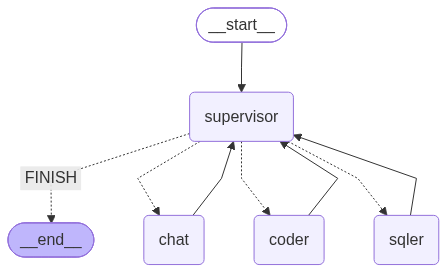

In [17]:
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
async for chunk in graph.astream({"messages":['我想查询数据库中data表的所有数据']}, stream_mode="updates"):
    for node_name, updates in chunk.items():
        for m in updates.get('messages', []):
            m.pretty_print()


================================ Human Message =================================
Name: sqler

我可以帮您提供查询数据库中data表所有数据的SQL语句。以下是几种常见数据库的查询方法：

## 1. **MySQL**
```sql
SELECT * FROM data;
```

## 2. **PostgreSQL**
```sql
SELECT * FROM data;
```

## 3. **SQL Server**
```sql
SELECT * FROM data;
```

## 4. **Oracle**
```sql
SELECT * FROM data;
```

## 5. **SQLite**
```sql
SELECT * FROM data;
```

## 更具体的查询方式

### 限制返回数量
```sql
-- MySQL/PostgreSQL/SQLite
SELECT * FROM data LIMIT 100;

-- SQL Server
SELECT TOP 100 * FROM data;

-- Oracle
SELECT * FROM data WHERE ROWNUM <= 100;
```

### 指定字段查询
```sql
SELECT column1, column2, column3 FROM data;
```

### 带条件的查询
```sql
SELECT * FROM data WHERE condition;
```

## 注意事项
- 如果表名是保留字，需要用反引号（MySQL）或双引号（其他数据库）括起来
- 如果数据量很大，建议添加LIMIT限制
- 确保有适当的权限访问该表

您使用的是哪种数据库？我可以提供更具体的帮助。
================================ Human Message =================================
Name: sqler

如果您想查询数据库中`data`表的所有数据，以下是几种常见数据库的SQL语句：

## 1. **MySQL / PostgreSQL / SQLite**
```sql
SELE

CancelledError: 